<a href="https://colab.research.google.com/github/NicholasMaestrello/01_nicholas_git/blob/master/Analise_Petroleo_AM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MBA em IA e BIGDATA
## DEPTO. SCC - ICMC - USP
## Desenvolvimento Inicial do Projeto de determinação do grau API extraindo dados das bases de Petróleo
## Bases extraidas do site da ANP

### **CURSO 2 - CD, AM e DM**
# Profa. Roseli A F Romero

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
fig = plt.gcf()
fig.set_size_inches(18.5, 10.5)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import missingno as msno

%matplotlib inline

from sklearn.feature_selection import SelectKBest, mutual_info_regression

import warnings

warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', 500)

<Figure size 1850x1050 with 0 Axes>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Leitura de dados e composição da base

Para acessar um diretório do Google Drive, o primeiro passo é montar o seu Drive no ambiente do Colab. Isso geralmente é feito com `from google.colab import drive` e `drive.mount('/content/drive')`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Defina o caminho para a sua pasta no Google Drive
# Substitua 'MinhaPastaNoDrive' pelo nome real da sua pasta.
# Por exemplo, se a sua pasta de dados se chama 'data-petro',
# o caminho seria '/content/drive/MyDrive/data-petro'

drive_directory_path = '/content/drive/MyDrive/data-petro'

# Para verificar os arquivos dentro do diretório, você pode usar os.listdir()
import os

if os.path.isdir(drive_directory_path):
    print(f"Conteúdo do diretório '{drive_directory_path}':")
    for item in os.listdir(drive_directory_path):
        print(item)
else:
    print(f"O diretório '{drive_directory_path}' não foi encontrado. Verifique o caminho ou se sua pasta existe no Google Drive.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
O diretório '/content/drive/MyDrive/data-petro' não foi encontrado. Verifique o caminho ou se sua pasta existe no Google Drive.


Depois de montar o Drive e ter o caminho correto para o seu diretório, você pode usar a função `absoluteFilePaths` que você já definiu, passando o caminho completo do Drive, por exemplo: `path_petro = list(absoluteFilePaths('/content/drive/MyDrive/data-petro'))`.

In [ ]:
import os

def absoluteFilePaths(directory):
    if not os.path.isdir(directory):
        print(f"Diretório '{directory}' não encontrado. Verifique se o caminho está correto e se o Google Drive está montado corretamente. Se seus dados estiverem no Google Drive, o caminho pode ser algo como '/content/drive/MyDrive/{nome_da_sua_pasta_de_dados}'.")
        return [] # Return empty list if directory not found

    files_found = False
    for dirpath,_,filenames in os.walk(directory):
        for f in filenames:
            # Exclude macOS metadata files (starting with '._') and .DS_Store files
            if not f.startswith('._') and not f == '.DS_Store':
                files_found = True
                yield os.path.abspath(os.path.join(dirpath, f))

    if not files_found:
        print(f"Nenhum arquivo de dados (excluindo arquivos de metadados macOS e .DS_Store) encontrado no diretório '{directory}'. Verifique se a pasta contém os arquivos esperados.")

# Para o CAMINHO_DA_PASTA_NO_DRIVE: Menu lateral esquerdo (ícone 📁) > drive > ache a pasta > clique nos 3 pontos > "Copiar caminho".
path_petro = list(absoluteFilePaths('CAMINHO_DA_PASTA_NO_DRIVE'))
# Verificar se a lista não está vazia antes de tentar acessar um elemento
if path_petro:
    print(path_petro[0])
else:
    print("A lista 'path_petro' está vazia. Nenhum arquivo de petróleo foi encontrado.")

Lemos os csv disponiveis para as datas de 202101 até 202204. Nesses csvs temos as representações das extrações de petróleo através do mar, pré-sal e terra.
Renomeamos as colunas e ajustamos os tipos de dados.

In [ ]:
path_mar = [path_mar for path_mar in path_petro if path_mar.lower().endswith('mar.csv')]
path_presal = [path_presal for path_presal in path_petro if path_presal.lower().endswith('presal.csv')]
path_terra = [path_terra for path_terra in path_petro if path_terra.lower().endswith('terra.csv')]

In [ ]:
df_mar = pd.concat((pd.read_csv(f, skiprows=3, sep = ';', decimal=",", thousands=".", header = None, encoding='latin1') for f in path_mar), ignore_index=True)
df_mar[48] = 'mar' #renomeando com o tipo de extração
print(df_mar.shape)

df_presal = pd.concat((pd.read_csv(f, skiprows=3, sep = ';', decimal=",", thousands=".", header = None, encoding='latin1') for f in path_presal), ignore_index=True)
df_presal[48] = 'presal' #renomeando com o tipo de extração
print(df_presal.shape)

df_terra = pd.concat((pd.read_csv(f, skiprows=3, sep = ';', decimal=",", thousands=".", header = None, encoding='latin1') for f in path_terra), ignore_index=True)
df_terra[48] = 'terra' #renomeando com o tipo de extração
print(df_terra.shape)

(20527, 49)
(5043, 49)
(158057, 49)


In [ ]:
df_petro = pd.concat([df_mar, df_presal, df_terra])
df_petro.reset_index(inplace = True, drop = True)
df_petro.shape

(183627, 49)

In [ ]:
columns = ['estado', 'bacia', 'nome_poco_anp', 'nome_poco_operador', 'campo', 'operador', 'numero_contrato', 'periodo', 'oleo_bbl_dia', 'condensado_bbl_dia', 'petroleo_bbl_dia', 'gas_ntrl_associado_mm3_dia','gas_ntrl_n_associado_mm3_dia','gas_ntrl_total_mm3_dia', 'vol_gas_mm3_dia', 'agua_bbl_dia', 'instalacao_destino', 'tipo_instalacao', 'tempo_producao_hrs_mes','periodo_carga', 'corrente', 'grau_api', 'frac_dest_leves_corte', 'frac_dest_leves_volume', 'frac_dest_medios_corte', 'frac_dest_medios_volume' , 'frac_dest_pesados_corte', 'frac_dest_pesados_volume', 'perc_vol_metano', 'perc_vol_etano', 'perc_vol_propano', 'perc_vol_isobutano', 'perc_vol_butano', 'perc_vol_isopentano', 'perc_vol_npentano', 'perc_vol_hexanos', 'perc_vol_heptanos', 'perc_vol_octanos', 'perc_vol_nonanos', 'perc_vol_decanos', 'perc_vol_undecanos', 'perc_vol_oxigenio', 'perc_vol_nitrogenio', 'perc_vol_co2', 'densidade_glp_gas', 'densidade_glp_liquido', 'pcs_gp_kj_m3', 'data_atualizacao', 'tipo_extracao']
df_petro.columns = columns
df_petro.head()

,estado,bacia,nome_poco_anp,nome_poco_operador,campo,operador,numero_contrato,periodo,oleo_bbl_dia,condensado_bbl_dia,petroleo_bbl_dia,gas_ntrl_associado_mm3_dia,gas_ntrl_n_associado_mm3_dia,gas_ntrl_total_mm3_dia,vol_gas_mm3_dia,agua_bbl_dia,instalacao_destino,tipo_instalacao,tempo_producao_hrs_mes,periodo_carga,corrente,grau_api,frac_dest_leves_corte,frac_dest_leves_volume,frac_dest_medios_corte,frac_dest_medios_volume,frac_dest_pesados_corte,frac_dest_pesados_volume,perc_vol_metano,perc_vol_etano,perc_vol_propano,perc_vol_isobutano,perc_vol_butano,perc_vol_isopentano,perc_vol_npentano,perc_vol_hexanos,perc_vol_heptanos,perc_vol_octanos,perc_vol_nonanos,perc_vol_decanos,perc_vol_undecanos,perc_vol_oxigenio,perc_vol_nitrogenio,perc_vol_co2,densidade_glp_gas,densidade_glp_liquido,pcs_gp_kj_m3,data_atualizacao,tipo_extracao
0,Rio de Janeiro,Santos,1-BRSA-1116-RJS,1RJS704,ITAPU,Petrobras,48610012913201005,2021/07,0.0000,0.0,0.0000,0.0000,0.0,0.0000,0.00000,0.0000,NaN,NaN,0,2020/02,Ãrea de Florim,29.3,< 270ÂºC,34.45%,270ÂºC a 458ÂºC,28.01%,> 458ÂºC,37.54%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,06/09/2021,mar
1,Rio de Janeiro,Santos,3-BRSA-1215-RJS,3RJS725,ITAPU,Petrobras,48610012913201005,2021/07,0.0000,0.0,0.0000,0.0000,0.0,0.0000,0.00000,0.0000,NaN,NaN,0,2020/02,Ãrea de Florim,29.3,< 270ÂºC,34.45%,270ÂºC a 458ÂºC,28.01%,> 458ÂºC,37.54%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,06/09/2021,mar
2,EspÃ­rito Santo,Campos,3-BRSA-149HP-ESS,3ESS110HP,JUBARTE,Petrobras,480000035609749,2021/07,4050.2598,0.0,4050.2598,38.8985,0.0,38.8985,1205.00832,25279.1786,PETROBRAS 57,UEP,714,2019/05,Parque das Baleias,26.1,< 290ÂºC,30.5%,290ÂºC a 380ÂºC,15.2%,> 380ÂºC,54.3%,79.928,9.111,5.099,0.926,1.733,0.424,0.565,0.949,0.328,0.11,0.037,0.022,0.0,0.001,0.635,0.132,2.03835,532.61496,40322.0363,06/09/2021,mar
3,EspÃ­rito Santo,Campos,7-JUB-4HP-ESS,7JUB4HPESS,JUBARTE,Petrobras,480000035609749,2021/07,2749.3330,0.0,2749.3330,21.6901,0.0,21.6901,671.92122,10316.5547,PETROBRAS 57,UEP,694,2019/05,Parque das Baleias,26.1,< 290ÂºC,30.5%,290ÂºC a 380ÂºC,15.2%,> 380ÂºC,54.3%,79.928,9.111,5.099,0.926,1.733,0.424,0.565,0.949,0.328,0.11,0.037,0.022,0.0,0.001,0.635,0.132,2.03835,532.61496,40322.0363,06/09/2021,mar
4,EspÃ­rito Santo,Campos,7-JUB-2HPA-ESS,7JUB2HPAESS,JUBARTE,Petrobras,480000035609749,2021/07,1808.9143,0.0,1808.9143,19.5330,0.0,19.5330,605.09732,2275.0291,PETROBRAS 57,UEP,697,2019/05,Parque das Baleias,26.1,< 290ÂºC,30.5%,290ÂºC a 380ÂºC,15.2%,> 380ÂºC,54.3%,79.928,9.111,5.099,0.926,1.733,0.424,0.565,0.949,0.328,0.11,0.037,0.022,0.0,0.001,0.635,0.132,2.03835,532.61496,40322.0363,06/09/2021,mar


In [ ]:
df_petro['frac_dest_leves_volume'] = df_petro['frac_dest_leves_volume'].str.rstrip('%').replace('', '0').astype('float') / 100.0
df_petro['frac_dest_medios_volume'] = df_petro['frac_dest_medios_volume'].str.rstrip('%').replace('', '0').astype('float') / 100.0
df_petro['frac_dest_pesados_volume'] = df_petro['frac_dest_pesados_volume'].str.rstrip('%').replace('', '0').astype('float') / 100.0

In [ ]:
df_petro.head()

,estado,bacia,nome_poco_anp,nome_poco_operador,campo,operador,numero_contrato,periodo,oleo_bbl_dia,condensado_bbl_dia,petroleo_bbl_dia,gas_ntrl_associado_mm3_dia,gas_ntrl_n_associado_mm3_dia,gas_ntrl_total_mm3_dia,vol_gas_mm3_dia,agua_bbl_dia,instalacao_destino,tipo_instalacao,tempo_producao_hrs_mes,periodo_carga,corrente,grau_api,frac_dest_leves_corte,frac_dest_leves_volume,frac_dest_medios_corte,frac_dest_medios_volume,frac_dest_pesados_corte,frac_dest_pesados_volume,perc_vol_metano,perc_vol_etano,perc_vol_propano,perc_vol_isobutano,perc_vol_butano,perc_vol_isopentano,perc_vol_npentano,perc_vol_hexanos,perc_vol_heptanos,perc_vol_octanos,perc_vol_nonanos,perc_vol_decanos,perc_vol_undecanos,perc_vol_oxigenio,perc_vol_nitrogenio,perc_vol_co2,densidade_glp_gas,densidade_glp_liquido,pcs_gp_kj_m3,data_atualizacao,tipo_extracao
0,Rio de Janeiro,Santos,1-BRSA-1116-RJS,1RJS704,ITAPU,Petrobras,48610012913201005,2021/07,0.0000,0.0,0.0000,0.0000,0.0,0.0000,0.00000,0.0000,NaN,NaN,0,2020/02,Ãrea de Florim,29.3,< 270ÂºC,0.3445,270ÂºC a 458ÂºC,0.2801,> 458ÂºC,0.3754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,06/09/2021,mar
1,Rio de Janeiro,Santos,3-BRSA-1215-RJS,3RJS725,ITAPU,Petrobras,48610012913201005,2021/07,0.0000,0.0,0.0000,0.0000,0.0,0.0000,0.00000,0.0000,NaN,NaN,0,2020/02,Ãrea de Florim,29.3,< 270ÂºC,0.3445,270ÂºC a 458ÂºC,0.2801,> 458ÂºC,0.3754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,06/09/2021,mar
2,EspÃ­rito Santo,Campos,3-BRSA-149HP-ESS,3ESS110HP,JUBARTE,Petrobras,480000035609749,2021/07,4050.2598,0.0,4050.2598,38.8985,0.0,38.8985,1205.00832,25279.1786,PETROBRAS 57,UEP,714,2019/05,Parque das Baleias,26.1,< 290ÂºC,0.3050,290ÂºC a 380ÂºC,0.1520,> 380ÂºC,0.5430,79.928,9.111,5.099,0.926,1.733,0.424,0.565,0.949,0.328,0.11,0.037,0.022,0.0,0.001,0.635,0.132,2.03835,532.61496,40322.0363,06/09/2021,mar
3,EspÃ­rito Santo,Campos,7-JUB-4HP-ESS,7JUB4HPESS,JUBARTE,Petrobras,480000035609749,2021/07,2749.3330,0.0,2749.3330,21.6901,0.0,21.6901,671.92122,10316.5547,PETROBRAS 57,UEP,694,2019/05,Parque das Baleias,26.1,< 290ÂºC,0.3050,290ÂºC a 380ÂºC,0.1520,> 380ÂºC,0.5430,79.928,9.111,5.099,0.926,1.733,0.424,0.565,0.949,0.328,0.11,0.037,0.022,0.0,0.001,0.635,0.132,2.03835,532.61496,40322.0363,06/09/2021,mar
4,EspÃ­rito Santo,Campos,7-JUB-2HPA-ESS,7JUB2HPAESS,JUBARTE,Petrobras,480000035609749,2021/07,1808.9143,0.0,1808.9143,19.5330,0.0,19.5330,605.09732,2275.0291,PETROBRAS 57,UEP,697,2019/05,Parque das Baleias,26.1,< 290ÂºC,0.3050,290ÂºC a 380ÂºC,0.1520,> 380ÂºC,0.5430,79.928,9.111,5.099,0.926,1.733,0.424,0.565,0.949,0.328,0.11,0.037,0.022,0.0,0.001,0.635,0.132,2.03835,532.61496,40322.0363,06/09/2021,mar


In [ ]:
df_petro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183627 entries, 0 to 183626
Data columns (total 49 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   estado                        183627 non-null  object 
 1   bacia                         183627 non-null  object 
 2   nome_poco_anp                 183627 non-null  object 
 3   nome_poco_operador            183627 non-null  object 
 4   campo                         183627 non-null  object 
 5   operador                      183627 non-null  object 
 6   numero_contrato               183627 non-null  object 
 7   periodo                       183627 non-null  object 
 8   oleo_bbl_dia                  183627 non-null  float64
 9   condensado_bbl_dia            183627 non-null  float64
 10  petroleo_bbl_dia              183627 non-null  float64
 11  gas_ntrl_associado_mm3_dia    183627 non-null  float64
 12  gas_ntrl_n_associado_mm3_dia  183627 non-nul

#### Detecção de missings

Veremos abaixo que algumas variáveis, principalmente atreladas aos subprodutos do petroleo possuem valores faltantes

In [ ]:
df_petro.isnull().sum()

,0
estado,0
bacia,0
nome_poco_anp,0
nome_poco_operador,0
campo,0
operador,0
numero_contrato,0
periodo,0
oleo_bbl_dia,0
condensado_bbl_dia,0


Retiramos, no entanto apenas as observações em que nossa futura variavel resposta está vazia

In [ ]:
df_petro = df_petro[df_petro['grau_api'].notna()]
df_petro.shape

(168210, 49)

#### Análise de colunas categoricas

In [ ]:
df_petro.info()

<class 'pandas.core.frame.DataFrame'>
Index: 168210 entries, 0 to 183626
Data columns (total 49 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   estado                        168210 non-null  object 
 1   bacia                         168210 non-null  object 
 2   nome_poco_anp                 168210 non-null  object 
 3   nome_poco_operador            168210 non-null  object 
 4   campo                         168210 non-null  object 
 5   operador                      168210 non-null  object 
 6   numero_contrato               168210 non-null  object 
 7   periodo                       168210 non-null  object 
 8   oleo_bbl_dia                  168210 non-null  float64
 9   condensado_bbl_dia            168210 non-null  float64
 10  petroleo_bbl_dia              168210 non-null  float64
 11  gas_ntrl_associado_mm3_dia    168210 non-null  float64
 12  gas_ntrl_n_associado_mm3_dia  168210 non-null  fl

In [ ]:
 categorical_cols = [
        'estado', 'bacia', 'nome_poco_anp', 'nome_poco_operador', 'campo', 'operador',
        'numero_contrato', 'periodo', 'instalacao_destino', 'tipo_instalacao',
        'periodo_carga', 'corrente', 'frac_dest_leves_corte',
        'frac_dest_medios_corte', 'frac_dest_pesados_corte', 'data_atualizacao',
        'tipo_extracao'
    ]


Dropamos algumas colunas que possuem informação repetida como visto acima. Ex: Bacia com Estado, nome_poco_anp, nome_poco_operador e campo

In [ ]:
df_petro.drop(['estado', 'nome_poco_anp', 'nome_poco_operador', 'campo', 'operador', 'numero_contrato', 'instalacao_destino', 'periodo_carga', 'corrente', 'frac_dest_leves_corte', 'frac_dest_medios_corte', 'frac_dest_pesados_corte', 'data_atualizacao'], axis = 1, inplace = True)
df_petro.shape

(168210, 36)

#### Análise das colunas contínuas

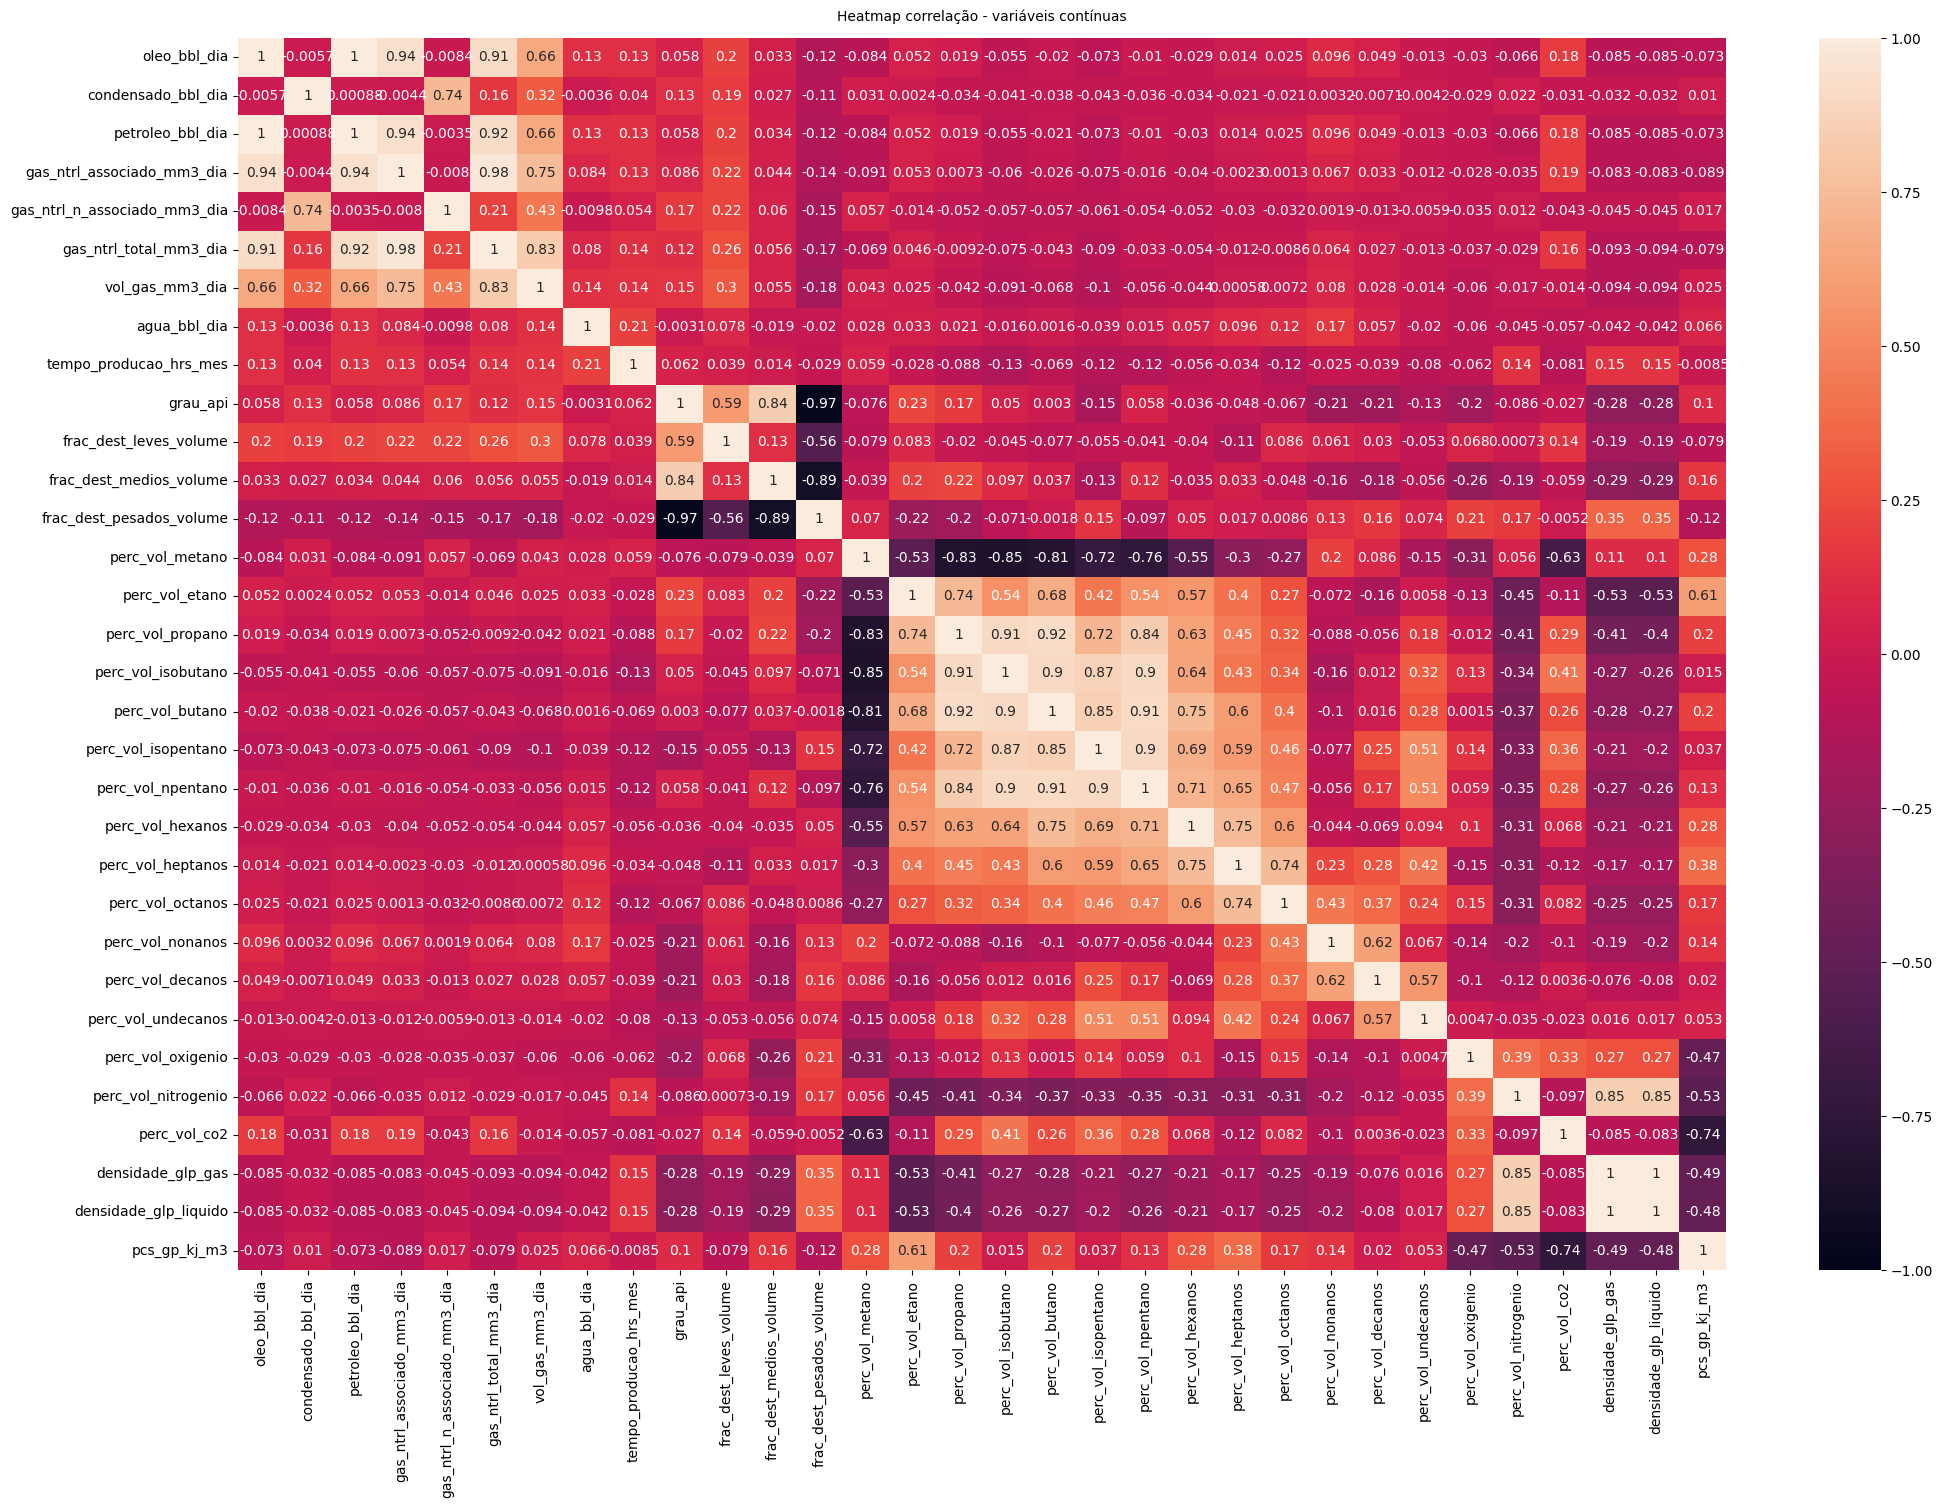

In [ ]:
plt.figure(figsize=(24, 16))
# Select only numeric columns for correlation calculation
numeric_df_petro = df_petro.select_dtypes(include=['float64', 'int64'])
heatmap = sns.heatmap(numeric_df_petro.corr(), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Heatmap correlação - variáveis contínuas', fontdict={'fontsize':10}, pad=12);

As variáveis oleo_bbl_dia e petroleo_bbl_dia são equivalentes e também possuem correlação fortissima com gas_ntrl_associado_mm3_dia e gas_ntrl_total_mm3_dia assim como densidade_glp_gas e densidade_glp_liquido e perc_vol_isobutano e perc_vol_butano. Visto isso, manteremos apenas algumas dessas variáveis

#### Criação de base sumarizada

Como a base possui muitas repetições, devido aos diferentes poços de extração e nossa análise se concentrar em uma abrangênia maior que é o campo, iremos realizar a sumarização dos dados pelas variáveis: bacia, periodo, tipo_producao e grau_api.

In [ ]:
df_petro.info()

<class 'pandas.core.frame.DataFrame'>
Index: 168210 entries, 0 to 183626
Data columns (total 36 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   bacia                         168210 non-null  object 
 1   periodo                       168210 non-null  object 
 2   oleo_bbl_dia                  168210 non-null  float64
 3   condensado_bbl_dia            168210 non-null  float64
 4   petroleo_bbl_dia              168210 non-null  float64
 5   gas_ntrl_associado_mm3_dia    168210 non-null  float64
 6   gas_ntrl_n_associado_mm3_dia  168210 non-null  float64
 7   gas_ntrl_total_mm3_dia        168210 non-null  float64
 8   vol_gas_mm3_dia               168210 non-null  float64
 9   agua_bbl_dia                  168210 non-null  float64
 10  tipo_instalacao               93119 non-null   object 
 11  tempo_producao_hrs_mes        168210 non-null  int64  
 12  grau_api                      168210 non-null  fl

In [ ]:
petro_sum = df_petro.groupby(['bacia', 'periodo', 'tipo_instalacao', 'tipo_extracao', 'grau_api'], as_index = False).agg(
    condensado_bbl_dia_sum = ('condensado_bbl_dia', sum),
    petroleo_bbldia_sum=('petroleo_bbl_dia', sum),
    gas_ntrl_n_associado_mm3_dia_sum=('gas_ntrl_n_associado_mm3_dia', sum),
    vol_gas_mm3dia_sum=('vol_gas_mm3_dia', sum),
    agua_bbl_dia_sum = ('agua_bbl_dia', sum),
    tempo_producao_hrs_mes_md = ('tempo_producao_hrs_mes', "median"),
    frac_dest_leves_volume_md = ('frac_dest_leves_volume', "median"),
    frac_dest_medios_volume_md = ('frac_dest_medios_volume', "median"),
    frac_dest_pesados_volume_md = ('frac_dest_pesados_volume', "median"),
    metano_md=('perc_vol_metano', "median"),
    etano_md=('perc_vol_etano', "median"),
    propano_md=('perc_vol_propano', "median"),
    butano_md=('perc_vol_butano', "median"),
    isopentano_md=('perc_vol_isopentano', "median"),
    npentano_md=('perc_vol_npentano', "median"),
    hexanos_md=('perc_vol_hexanos', "median"),
    heptanos_md=('perc_vol_heptanos', "median"),
    octanos_md=('perc_vol_octanos', "median"),
    nonanos_md=('perc_vol_nonanos', "median"),
    decanos_md = ('perc_vol_decanos', "median"),
    undecanos_md = ('perc_vol_undecanos', "median"),
    oxigenio_md=('perc_vol_oxigenio', "median"),
    nitrogenio_md=('perc_vol_nitrogenio', "median"),
    co2_md=('perc_vol_co2', "median"),
    dens_glp_gas_md=('densidade_glp_gas', "median"),
    pcs_gp_kjm3_md=('pcs_gp_kj_m3', "median"),
)
#Aproveitamos também para renomear as colunas que tem nome com espaço

petro_sum

,bacia,periodo,tipo_instalacao,tipo_extracao,grau_api,condensado_bbl_dia_sum,petroleo_bbldia_sum,gas_ntrl_n_associado_mm3_dia_sum,vol_gas_mm3dia_sum,agua_bbl_dia_sum,tempo_producao_hrs_mes_md,frac_dest_leves_volume_md,frac_dest_medios_volume_md,frac_dest_pesados_volume_md,metano_md,etano_md,propano_md,butano_md,isopentano_md,npentano_md,hexanos_md,heptanos_md,octanos_md,nonanos_md,decanos_md,undecanos_md,oxigenio_md,nitrogenio_md,co2_md,dens_glp_gas_md,pcs_gp_kjm3_md
0,Alagoas,2021/01,INSTALACAO EMB/DESEMB,mar,40.8,56.7972,56.7972,142.7179,4424.25429,0.0000,744.0,0.3074,0.4866,0.206,85.44,7.66,2.66,0.80,0.21,0.27,0.22,0.04,0.07,0.01,0.04,0.02,0.00,1.72,0.45,2.01783,39158.4001
1,Alagoas,2021/01,INSTALACAO EMB/DESEMB,terra,26.2,0.0000,206.8524,0.0000,42.22187,624.8299,0.0,0.2780,0.1340,0.588,85.99,4.48,5.12,1.38,0.30,0.22,0.12,0.00,0.00,0.00,0.00,0.00,0.00,1.06,0.35,2.02017,38572.2572
2,Alagoas,2021/01,INSTALACAO EMB/DESEMB,terra,40.8,21.5171,1862.2855,283.5897,14886.00234,5922.9514,724.0,0.3074,0.4866,0.206,81.18,9.38,3.51,0.91,0.21,0.28,0.28,0.02,0.07,0.01,0.01,0.02,0.00,3.37,0.22,2.00670,39135.0095
3,Alagoas,2021/02,INSTALACAO EMB/DESEMB,mar,40.8,57.5363,57.5363,157.3306,4405.25580,0.0000,672.0,0.3074,0.4866,0.206,85.44,7.66,2.66,0.80,0.21,0.27,0.22,0.04,0.07,0.01,0.04,0.02,0.00,1.72,0.45,2.01783,39158.4001
4,Alagoas,2021/02,INSTALACAO EMB/DESEMB,terra,26.2,0.5544,250.5119,0.1681,47.99309,814.7876,0.0,0.2780,0.1340,0.588,85.99,4.48,5.12,1.38,0.30,0.22,0.12,0.00,0.00,0.00,0.00,0.00,0.00,1.06,0.35,2.02017,38572.2572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1196,Tucano Sul,2021/04,INSTALACAO EMB/DESEMB,terra,36.5,1.9789,1.9789,21.6087,648.26139,0.8890,89.0,0.2022,0.4958,0.302,65.77,18.84,7.94,2.00,0.60,0.70,0.50,0.15,0.00,0.00,0.00,0.00,0.40,2.62,0.18,1.96786,42510.2667
1197,Tucano Sul,2021/05,INSTALACAO EMB/DESEMB,terra,36.5,2.4979,2.4979,19.3489,599.82031,0.2776,212.5,0.2022,0.4958,0.302,66.61,15.10,7.20,2.57,1.71,1.34,0.63,0.62,0.28,0.16,0.22,0.00,0.04,0.98,0.28,2.07357,42364.3722
1198,Tucano Sul,2021/06,INSTALACAO EMB/DESEMB,terra,36.5,2.3087,2.3087,20.6397,619.19076,0.5592,195.5,0.2022,0.4958,0.302,84.07,9.95,3.03,0.78,0.00,0.39,0.35,0.35,0.00,0.00,0.00,0.00,0.03,0.30,0.02,2.03170,40591.0426
1199,Tucano Sul,2021/07,INSTALACAO EMB/DESEMB,terra,36.5,1.9594,1.9594,21.7079,672.94655,0.3788,358.0,0.2022,0.4958,0.302,87.25,8.86,2.49,0.60,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.18,0.03,2.02393,40260.6866


A tabela reduziu o tamanho significamente ao se desconsiderar a produção individual por poços

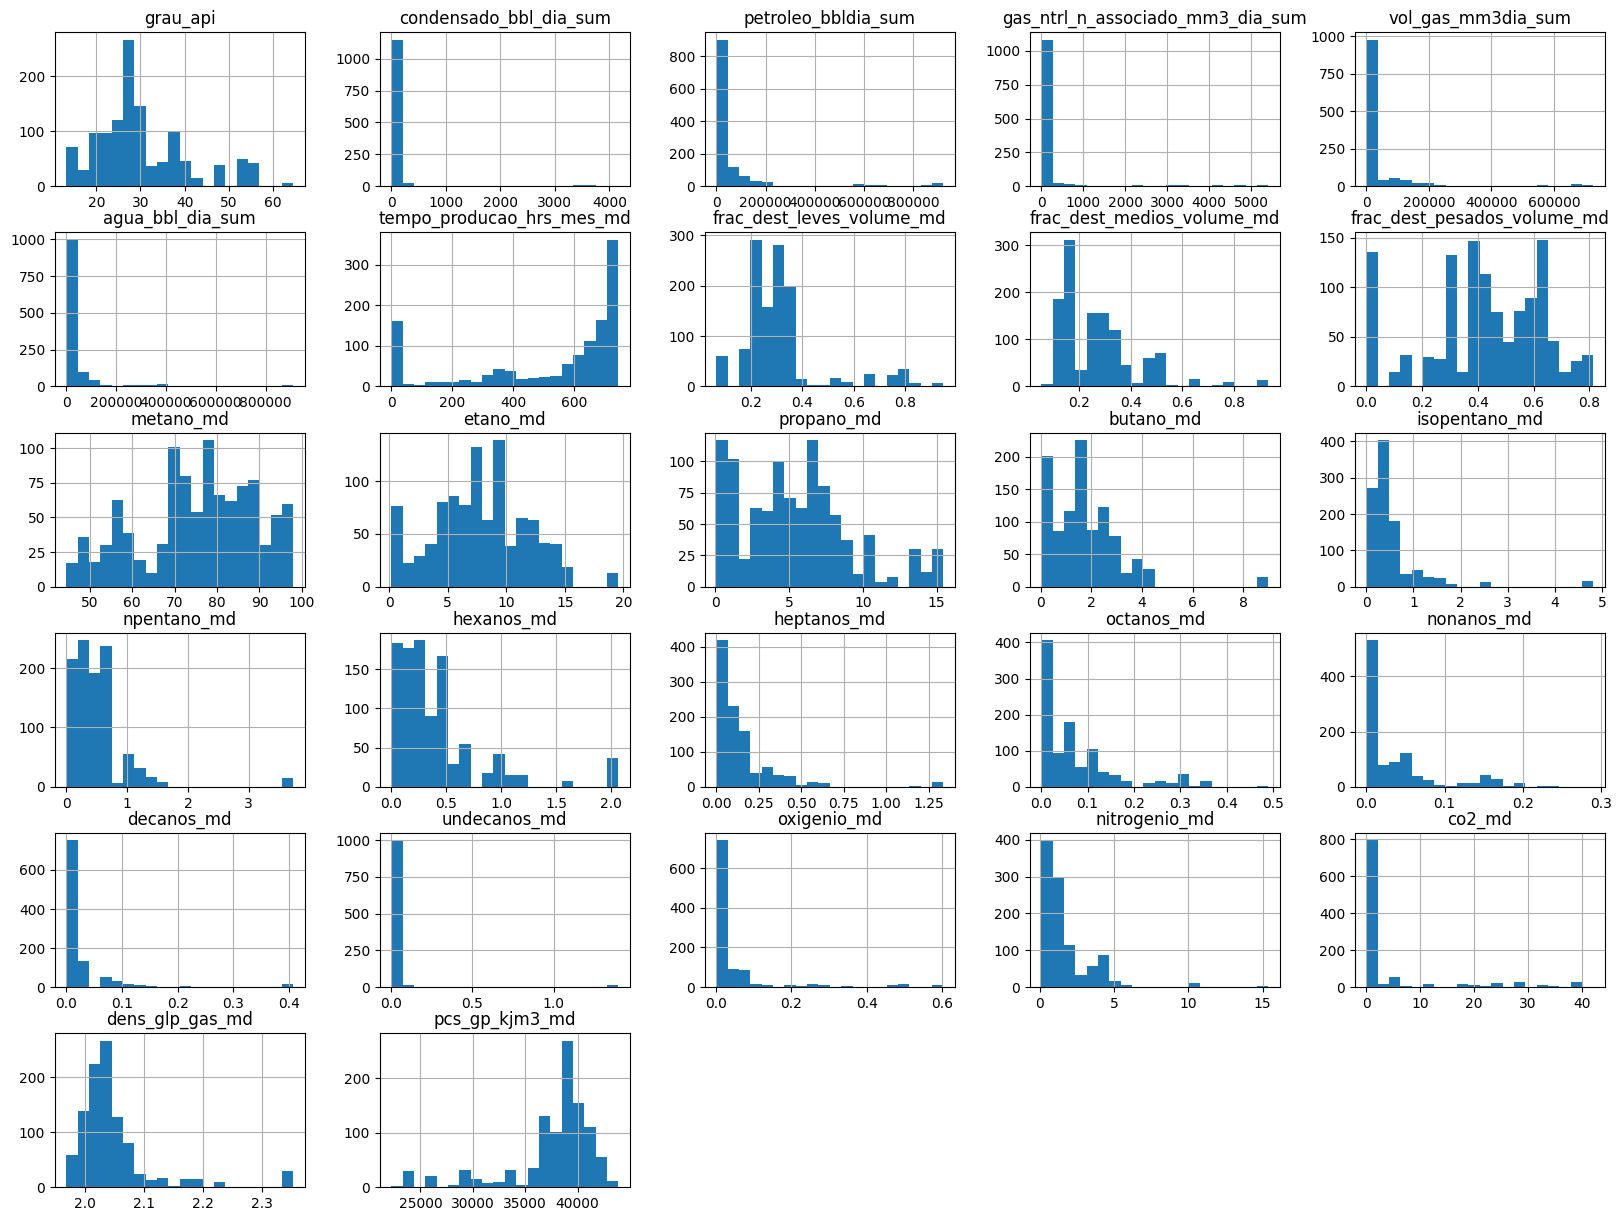

In [ ]:
petro_sum.hist(bins=20, figsize=(20,15))
plt.show()

To check for unique values in a column, you can use the `.unique()` method. This is particularly useful for categorical columns to see all possible categories.

In [ ]:
print("Unique values in 'bacia' column:")
print(df_petro['bacia'].unique())

print("\nUnique values in 'tipo_extracao' column:")
print(df_petro['tipo_extracao'].unique())

Unique values in 'bacia' column:
['Santos' 'Campos' 'RecÃ´ncavo' 'CearÃ¡' 'EspÃ\xadrito Santo' 'Camamu'
 'Potiguar' 'Alagoas' 'Sergipe' 'SolimÃµes' 'ParnaÃ\xadba' 'Tucano Sul'
 'Amazonas']

Unique values in 'tipo_extracao' column:
['mar' 'presal' 'terra']


To effectively understand the missing data, it's helpful to see both the count and the percentage of null values for each column.

In [ ]:
# Calculate the total number of null values per column
null_counts = df_petro.isnull().sum()

# Calculate the percentage of null values per column
null_percentages = (df_petro.isnull().sum() / len(df_petro)) * 100

# Create a DataFrame to display these values
missing_data_info = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage': null_percentages
})

# Filter to show only columns with missing values and sort by percentage
missing_data_info = missing_data_info[missing_data_info['Null Count'] > 0].sort_values(by='Null Percentage', ascending=False)

display(missing_data_info)

,Null Count,Null Percentage
tipo_instalacao,75091,44.641222
perc_vol_metano,43825,26.053742
perc_vol_etano,43825,26.053742
perc_vol_propano,43825,26.053742
perc_vol_isobutano,43825,26.053742
perc_vol_butano,43825,26.053742
perc_vol_isopentano,43825,26.053742
perc_vol_npentano,43825,26.053742
perc_vol_hexanos,43825,26.053742
perc_vol_heptanos,43825,26.053742


#### Criando o conjunto de teste
Criamos o conjunto de treino e teste nessa etapa a fim de evitar data leakage. A seleção de features pode ser feita usando o conjunto de treinamento

In [ ]:
X = petro_sum.drop(columns = 'grau_api')
y = petro_sum[['grau_api']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=28)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(960, 30)
(960, 1)
(241, 30)
(241, 1)


Identificamos e preenchemos os valores faltantes através da interpolação linear considerando a variável 'bacia' como base

In [ ]:
nan_cols = [i for i in X.columns if X[i].isnull().any()]
for col in nan_cols:
    X_train[col] = X_train.groupby('bacia')[col].transform(lambda x: x.interpolate(method='linear').bfill())
    X_test[col] = X_test.groupby('bacia')[col].transform(lambda x: x.interpolate(method='linear').bfill())

#### Transformando dados categóricos em dummies

In [ ]:
X_train= pd.get_dummies(X_train, columns = ['bacia', 'tipo_extracao', 'tipo_instalacao'])
X_train.drop(columns = 'periodo', inplace = True)
X_test= pd.get_dummies(X_test, columns = ['bacia', 'tipo_extracao', 'tipo_instalacao'])
X_test.drop(columns = 'periodo', inplace = True)
print(X_train.shape)
print(X_test.shape)

(960, 43)
(241, 43)


#### Seleção de features
Faremos duas seleções de features e trabalharemos com esses dois conjuntos para identificar qual o traz uma melhor performance para predizer o grau_api, ou seja, a qualidade do petroleo e pra qual finalidade o usaremos

##### Mutual Information Score

In [ ]:
discrete_features = [False]*26 + [True]*17
feature_scores = mutual_info_regression(X_train, y_train, discrete_features=discrete_features, random_state = 28)
df_score = pd.DataFrame(list(dict(sorted(zip(X_train.columns, feature_scores), reverse = True)).items())).rename(columns = {0:'variavel', 1: 'mis'}).sort_values('mis', ascending = False)

In [ ]:
df_score['cum_sum'] = df_score['mis'].cumsum()
df_score['cum_perc'] = 100*df_score['cum_sum']/df_score['mis'].sum()
df_score.reset_index(drop = True, inplace= True)
df_score.head()


,variavel,mis,cum_sum,cum_perc
0,frac_dest_leves_volume_md,4.000208,4.000208,5.597283
1,frac_dest_medios_volume_md,3.968608,7.968816,11.150349
2,frac_dest_pesados_volume_md,3.912089,11.880905,16.624331
3,pcs_gp_kjm3_md,3.321406,15.202311,21.271801
4,metano_md,3.301151,18.503462,25.890930


Total de variaveis a ser consideradas com 90% do Mutual Information Score: 21


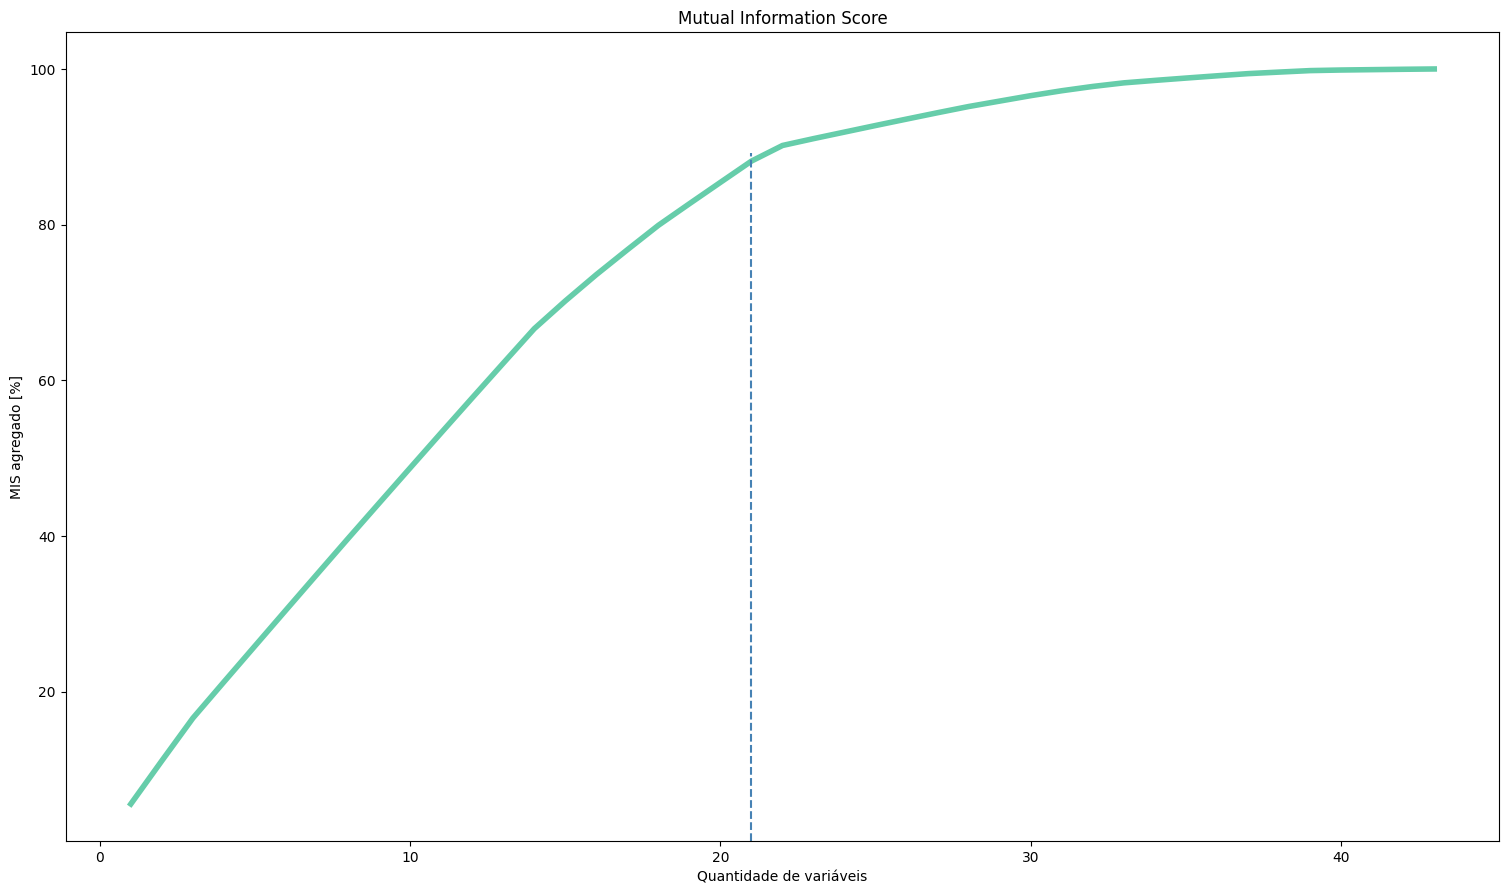

In [ ]:
import numpy as np
X = np.arange(start = 1, stop = len(df_score)+1)
y = df_score['cum_perc']

fig = plt.gcf()
fig.set_size_inches(18.5, 10.5)
plt.plot(X, y, color = 'mediumaquamarine', linewidth = 4)
x = len(y[y<90])
plt.axvline(x = x, ymin = 0, ymax = 0.85, linestyle = '--', color = 'steelblue', label = '90%')
plt.title('Mutual Information Score')
plt.ylabel('MIS agregado [%]')
plt.xlabel('Quantidade de variáveis')
print("Total de variaveis a ser consideradas com 90% do Mutual Information Score:", x)


In [ ]:
covars_mis = df_score.variavel[:21].tolist()
covars_mis

['frac_dest_leves_volume_md',
 'frac_dest_medios_volume_md',
 'frac_dest_pesados_volume_md',
 'pcs_gp_kjm3_md',
 'metano_md',
 'etano_md',
 'co2_md',
 'propano_md',
 'nitrogenio_md',
 'dens_glp_gas_md',
 'butano_md',
 'npentano_md',
 'isopentano_md',
 'hexanos_md',
 'heptanos_md',
 'octanos_md',
 'petroleo_bbldia_sum',
 'nonanos_md',
 'oxigenio_md',
 'vol_gas_mm3dia_sum',
 'agua_bbl_dia_sum']

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
#Selecting the Best important features according to Logistic Regression
sfs_selector = SequentialFeatureSelector(estimator=LinearRegression(), n_features_to_select = 21, cv =10, direction ='backward')
sfs_selector.fit(X_train, y_train)
covars_sfs = list(X_train.columns[sfs_selector.get_support()])
covars_sfs

['condensado_bbl_dia_sum',
 'vol_gas_mm3dia_sum',
 'frac_dest_medios_volume_md',
 'frac_dest_pesados_volume_md',
 'metano_md',
 'etano_md',
 'propano_md',
 'isopentano_md',
 'hexanos_md',
 'heptanos_md',
 'undecanos_md',
 'dens_glp_gas_md',
 'pcs_gp_kjm3_md',
 'bacia_Alagoas',
 'bacia_Campos',
 'bacia_EspÃ\xadrito Santo',
 'bacia_Potiguar',
 'bacia_Santos',
 'bacia_Sergipe',
 'bacia_SolimÃµes',
 'tipo_extracao_terra']

#### Aplicação para modelagem

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
from sklearn.metrics import explained_variance_score, mean_squared_error

param_distribs = {
        'n_estimators': randint(low=1, high=200),
        'max_features': randint(low=1, high=8),
    }

forest_reg_mis = RandomForestRegressor(random_state=28)
rnd_search_mis = RandomizedSearchCV(forest_reg_mis, param_distributions=param_distribs,
                                n_iter=100, cv=5, scoring='neg_mean_squared_error', random_state=28)
rnd_search_mis.fit(X_train[covars_mis], y_train)
negative_mse_mis = rnd_search_mis.best_score_
rmse_mis = np.sqrt(-negative_mse_mis)
print(rmse_mis)

forest_reg_sfs = RandomForestRegressor(random_state=28)
rnd_search_sfs = RandomizedSearchCV(forest_reg_sfs, param_distributions=param_distribs,
                                n_iter=100, cv=5, scoring='neg_mean_squared_error', random_state=28)
rnd_search_sfs.fit(X_train[covars_sfs], y_train)
negative_mse_sfs = rnd_search_sfs.best_score_
rmse_sfs = np.sqrt(-negative_mse_sfs)
print(rmse_sfs)

0.6472139728683988
0.9838402666953463


In [ ]:
predict_rf_mis = rnd_search_mis.predict(X_test[covars_mis])
print(rnd_search_mis.best_params_)
print(f'Variância Explicada pela random forest: {explained_variance_score(predict_rf_mis, y_test):.2f}')
print(f'MSE pela random forest: {mean_squared_error(predict_rf_mis, y_test):.2f}')

{'max_features': 7, 'n_estimators': 108}
Variância Explicada pela random forest: 1.00
MSE pela random forest: 0.21


In [ ]:
predict_rf_sfs = rnd_search_sfs.predict(X_test[covars_sfs])
print(rnd_search_sfs.best_params_)
print(f'Variância Explicada pela random forest: {explained_variance_score(predict_rf_sfs, y_test):.2f}')
print(f'MSE pela random forest: {mean_squared_error(predict_rf_sfs, y_test):.2f}')

{'max_features': 7, 'n_estimators': 102}
Variância Explicada pela random forest: 0.99
MSE pela random forest: 0.63


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import explained_variance_score, mean_squared_error
param_distribs = { 'max_depth': [3, 5, 6, 10, 15, 20],
           'learning_rate': [0.01, 0.1, 0.2, 0.3],
           'subsample': np.arange(0.5, 1.0, 0.1),
           'colsample_bytree': np.arange(0.4, 1.0, 0.1),
           'colsample_bylevel': np.arange(0.4, 1.0, 0.1),
           'n_estimators': [100, 500, 1000]}


xg_reg_mis = XGBRegressor(seed = 28)
xg_rnd_search_mis = RandomizedSearchCV(xg_reg_mis, param_distributions=param_distribs,
                                n_iter=100, cv=5, scoring='neg_mean_squared_error', verbose = 1, random_state=28)
xg_rnd_search_mis.fit(X_train[covars_mis], y_train)
xg_negative_mse_mis = xg_rnd_search_mis.best_score_
xg_rmse_mis = np.sqrt(-xg_negative_mse_mis)
print(xg_rmse_mis)

xg_reg_sfs = XGBRegressor(seed=28)
xg_rnd_search_sfs = RandomizedSearchCV(xg_reg_sfs, param_distributions=param_distribs,
                                n_iter=100, cv=5, scoring='neg_mean_squared_error', verbose = 1, random_state=28)
xg_rnd_search_sfs.fit(X_train[covars_sfs], y_train)
xg_negative_mse_sfs = xg_rnd_search_sfs.best_score_
xg_rmse_sfs = np.sqrt(-xg_negative_mse_sfs)
print(xg_rmse_sfs)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
0.40153007914511757
Fitting 5 folds for each of 100 candidates, totalling 500 fits
0.6208539103825166


In [ ]:
predict_xg_mis = xg_rnd_search_mis.predict(X_test[covars_mis])
print(xg_rnd_search_mis.best_params_)
print(f'Variância Explicada pelo xg: {explained_variance_score(predict_xg_mis, y_test):.2f}')
print(f'MSE pelo xg: {mean_squared_error(predict_xg_mis, y_test):.2f}')

{'subsample': np.float64(0.6), 'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': np.float64(0.8999999999999999), 'colsample_bylevel': np.float64(0.7)}
Variância Explicada pelo xg: 1.00
MSE pelo xg: 0.07


In [ ]:
predict_xg_sfs = xg_rnd_search_sfs.predict(X_test[covars_sfs])
print(xg_rnd_search_sfs.best_params_)
print(f'Variância Explicada pelo xg: {explained_variance_score(predict_xg_sfs, y_test):.2f}')
print(f'MSE pelo xg: {mean_squared_error(predict_xg_sfs, y_test):.2f}')

{'subsample': np.float64(0.8999999999999999), 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.3, 'colsample_bytree': np.float64(0.5), 'colsample_bylevel': np.float64(0.7)}
Variância Explicada pelo xg: 1.00
MSE pelo xg: 0.25
